In [10]:
import sqlite3
import pandas as pd

# Create or overwrite northstar.db in this Python session
conn = sqlite3.connect("northstar.db")

# Load CSVs into DataFrames
customers  = pd.read_csv("customers_cleaned.csv")
drivers    = pd.read_csv("drivers_cleaned.csv")
vehicles   = pd.read_csv("vehicles_cleaned.csv")
orders     = pd.read_csv("orders_cleaned.csv")
deliveries = pd.read_csv("deliveries_cleaned.csv")
incidents  = pd.read_csv("incidents_cleaned.csv")
complaints = pd.read_csv("complaints_cleaned.csv")
app_events = pd.read_csv("app_events_cleaned.csv")
hubs       = pd.read_csv("hubs_cleaned.csv")

# Write to SQLite tables
customers.to_sql("customers", conn, if_exists="replace", index=False)
drivers.to_sql("drivers", conn, if_exists="replace", index=False)
vehicles.to_sql("vehicles", conn, if_exists="replace", index=False)
orders.to_sql("orders", conn, if_exists="replace", index=False)
deliveries.to_sql("deliveries", conn, if_exists="replace", index=False)
incidents.to_sql("incidents", conn, if_exists="replace", index=False)
complaints.to_sql("complaints", conn, if_exists="replace", index=False)
app_events.to_sql("app_events", conn, if_exists="replace", index=False)
hubs.to_sql("hubs", conn, if_exists="replace", index=False)

# Check tables now exist
tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)
print(tables)

         name
0   customers
1     drivers
2    vehicles
3      orders
4  deliveries
5   incidents
6  complaints
7  app_events
8        hubs


In [11]:
deliveries = pd.read_sql_query("SELECT * FROM deliveries LIMIT 5;", conn)
print(deliveries.head())

  delivery_id order_id driver_id vehicle_id hub_id        dispatch_time  \
0     DL00001   O00938      D004       V056    H05  2024-06-18 10:57:00   
1     DL00002   O00004      D138       V007    H02  2025-01-11 18:45:00   
2     DL00003   O00639      D006       V049    H02  2025-06-02 20:39:00   
3     DL00004   O00313      D116       V055    H02  2024-03-08 23:31:00   
4     DL00005   O00844      D108       V034    H01  2025-09-21 11:43:00   

        delivery_completed_at delivery_status  route_distance_km  \
0  2024-06-19 09:05:59.904311          Failed              17.26   
1  2025-01-11 17:39:00.000000          OnTime              10.34   
2  2025-06-02 21:45:32.366770          OnTime               7.92   
3  2024-03-09 23:30:08.103702         Delayed              16.42   
4  2025-09-21 15:45:34.131056          OnTime              14.52   

   manual_route_override_count  proof_of_completion_missing  \
0                            1                            0   
1             

In [12]:
import numpy as np

deliveries["dispatch_time"] = pd.to_datetime(deliveries["dispatch_time"])
deliveries["delivery_completed_at"] = pd.to_datetime(deliveries["delivery_completed_at"])

mask = deliveries["dispatch_time"].notna() & deliveries["delivery_completed_at"].notna()
deliveries.loc[mask, "delivery_minutes"] = (
    (deliveries.loc[mask, "delivery_completed_at"] - deliveries.loc[mask, "dispatch_time"])
    .dt.total_seconds() / 60
)

deliveries["delivery_minutes"].describe()

,delivery_minutes
count,5.000000
mean,602.248353
std,723.093051
min,-66.000000
25%,66.539446
50%,242.568851
75%,1328.998405
max,1439.135062


In [13]:
driver_perf = (
    deliveries
    .dropna(subset=["delivery_minutes"])
    .groupby("driver_id", as_index=False)
    .agg(avg_delivery_minutes=("delivery_minutes", "mean"),
         deliveries_count=("delivery_id", "count"))
    .sort_values("avg_delivery_minutes", ascending=False)
)

driver_perf.head()

,driver_id,avg_delivery_minutes,deliveries_count
3,D116,1439.135062,1
0,D004,1328.998405,1
2,D108,242.568851,1
1,D006,66.539446,1
4,D138,-66.000000,1


/tmp/ipykernel_9273/976982933.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


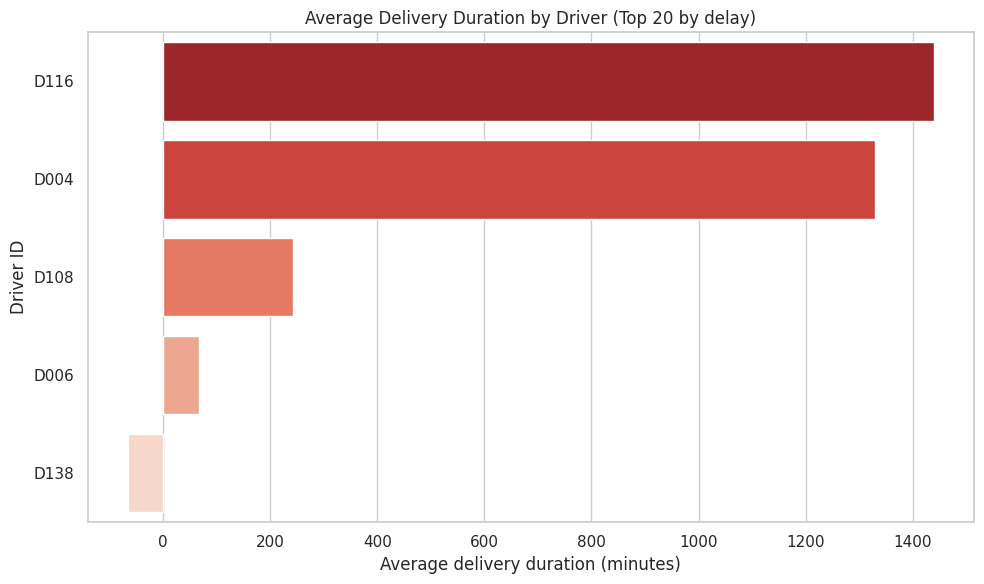

In [14]:
plt.figure(figsize=(10, 6))
top_n = driver_perf.head(20)

sns.barplot(
    data=top_n,
    x="avg_delivery_minutes",
    y="driver_id",
    palette="Reds_r"
)
plt.title("Average Delivery Duration by Driver (Top 20 by delay)")
plt.xlabel("Average delivery duration (minutes)")
plt.ylabel("Driver ID")
plt.tight_layout()
plt.show()

In [15]:
vehicle_impact = (
    deliveries
    .dropna(subset=["delivery_minutes"])
    .groupby("vehicle_id", as_index=False)
    .agg(avg_delivery_minutes=("delivery_minutes", "mean"),
         deliveries_count=("delivery_id", "count"))
    .sort_values("avg_delivery_minutes", ascending=False)
)

vehicle_impact.head()

,vehicle_id,avg_delivery_minutes,deliveries_count
3,V055,1439.135062,1
4,V056,1328.998405,1
1,V034,242.568851,1
2,V049,66.539446,1
0,V007,-66.000000,1


In [16]:
vehicles = pd.read_sql_query("SELECT * FROM vehicles;", conn)

deliv_vehicle = deliveries.merge(vehicles, on="vehicle_id", how="left")

veh_impact = (
    deliv_vehicle
    .dropna(subset=["delivery_minutes"])
    .groupby(["vehicle_type", "maintenance_status"], as_index=False)
    .agg(avg_delivery_minutes=("delivery_minutes", "mean"),
         deliveries_count=("delivery_id", "count"))
)

veh_impact.head()

,vehicle_type,maintenance_status,avg_delivery_minutes,deliveries_count
0,Diesel,Active,0.269723,2
1,EV,Active,1328.998405,1
2,EV,InRepair,242.568851,1
3,Hybrid,Active,1439.135062,1


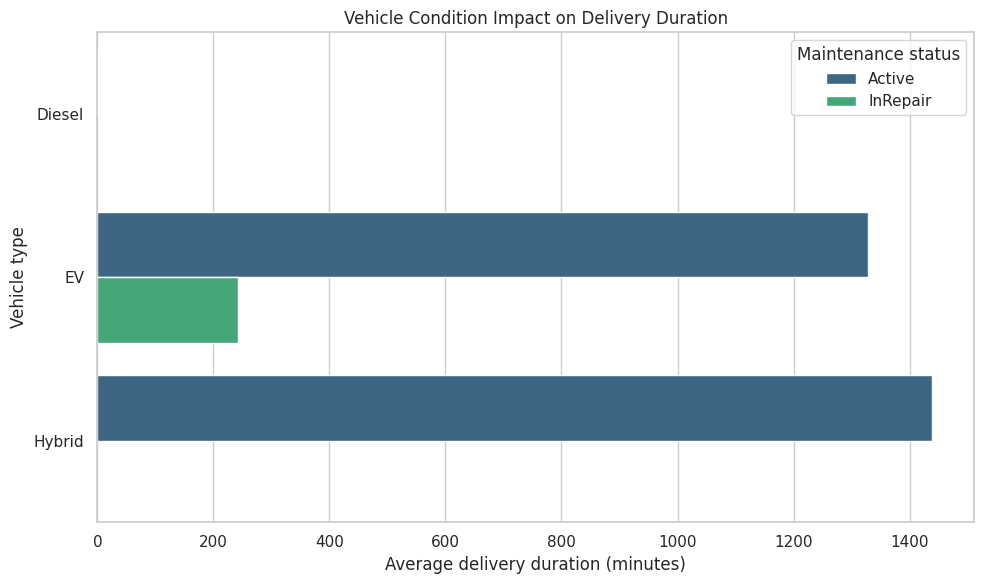

In [17]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=veh_impact,
    x="avg_delivery_minutes",
    y="vehicle_type",
    hue="maintenance_status",
    palette="viridis"
)
plt.title("Vehicle Condition Impact on Delivery Duration")
plt.xlabel("Average delivery duration (minutes)")
plt.ylabel("Vehicle type")
plt.legend(title="Maintenance status")
plt.tight_layout()
plt.show()

In [18]:
incidents = pd.read_sql_query("SELECT * FROM incidents;", conn)

deliv_inc = deliveries.merge(
    incidents[["incident_id", "delivery_id"]],
    on="delivery_id",
    how="left"
)

deliv_inc["has_incident"] = deliv_inc["incident_id"].notna()

incident_impact = (
    deliv_inc
    .dropna(subset=["delivery_minutes"])
    .groupby("has_incident", as_index=False)
    .agg(avg_delivery_minutes=("delivery_minutes", "mean"),
         deliveries_count=("delivery_id", "count"))
)

incident_impact

,has_incident,avg_delivery_minutes,deliveries_count
0,False,420.560840,4
1,True,1328.998405,1


/tmp/ipykernel_9273/3611033012.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


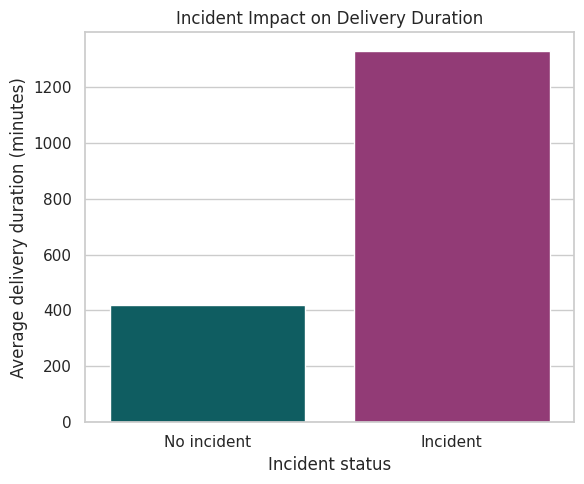

In [19]:
plt.figure(figsize=(6, 5))
sns.barplot(
    data=incident_impact,
    x="has_incident",
    y="avg_delivery_minutes",
    palette=["#01696f", "#a12c7b"]
)
plt.xticks([0, 1], ["No incident", "Incident"])
plt.title("Incident Impact on Delivery Duration")
plt.xlabel("Incident status")
plt.ylabel("Average delivery duration (minutes)")
plt.tight_layout()
plt.show()

In [20]:
overrides_df = deliveries.dropna(subset=["delivery_minutes", "manual_route_override_count"])

overrides_df[["manual_route_override_count", "delivery_minutes"]].head()

,manual_route_override_count,delivery_minutes
0,1,1328.998405
1,1,-66.000000
2,0,66.539446
3,0,1439.135062
4,1,242.568851


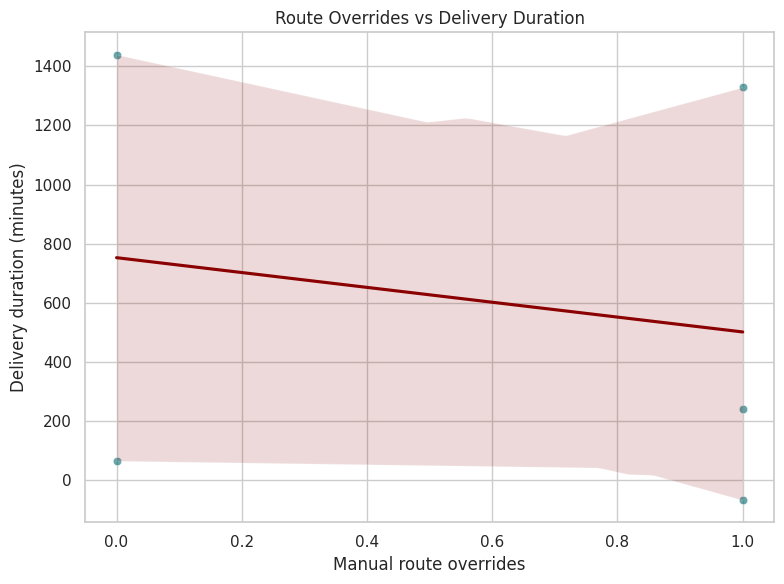

In [21]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=overrides_df,
    x="manual_route_override_count",
    y="delivery_minutes",
    alpha=0.6,
    color="#01696f"
)
sns.regplot(
    data=overrides_df,
    x="manual_route_override_count",
    y="delivery_minutes",
    scatter=False,
    color="darkred"
)
plt.title("Route Overrides vs Delivery Duration")
plt.xlabel("Manual route overrides")
plt.ylabel("Delivery duration (minutes)")
plt.tight_layout()
plt.show()

In [22]:
cost_df = deliveries.dropna(subset=["route_distance_km", "fuel_or_charge_cost"])

cost_df["cost_per_km"] = cost_df["fuel_or_charge_cost"] / cost_df["route_distance_km"]

cost_df[["route_distance_km", "fuel_or_charge_cost", "cost_per_km"]].head()

,route_distance_km,fuel_or_charge_cost,cost_per_km
0,17.26,12.05,0.698146
1,10.34,13.41,1.296905
2,7.92,8.51,1.074495
3,16.42,13.62,0.829476
4,14.52,9.22,0.634986


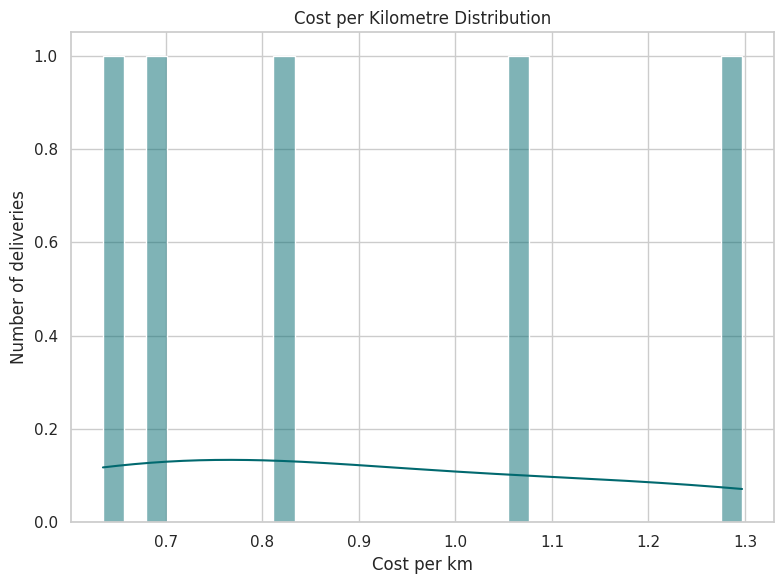

In [23]:
plt.figure(figsize=(8, 6))
sns.histplot(
    data=cost_df,
    x="cost_per_km",
    bins=30,
    kde=True,
    color="#01696f"
)
plt.title("Cost per Kilometre Distribution")
plt.xlabel("Cost per km")
plt.ylabel("Number of deliveries")
plt.tight_layout()
plt.show()

In [24]:
conn.close()